# Time-Series Cross-Series Correlation & Cross-Lagged Analysis (EDA Part 7)
## Hourly Pharmaceutical Sales Forecasting Dataset

---

### Executive Summary & Notebook Overview
This notebook executes a dedicated **Cross-Series Correlation and Cross-Series Lagged Correlation Analysis** for the hourly pharmaceutical sales dataset (`dataset/saleshourly.csv`). While previous notebooks examined univariate dynamics, this notebook evaluates multivariate relationships across all 8 ATC drug categories (`M01AB`, `M01AE`, `N02BA`, `N02BE`, `N05B`, `N05C`, `R03`, `R06`). The goal is to uncover co-purchasing demand clusters, cross-category lead-lag dependencies ($X_{t-k} 	o Y_t$), and exogenous feature opportunities for multivariate forecasting models (VAR, LightGBM, XGBoost, Multi-target LSTMs).

---

### Table of Contents
1. [35. Cross-Series Correlation](#35.-Cross-Series-Correlation)
2. [36. Cross-Series Lagged Correlation](#36.-Cross-Series-Lagged-Correlation)
3. [37. Summary of Findings & Key Takeaways](#37.-Summary-of-Findings-&-Key-Takeaways)

---


In [1]:
# Environment setup & library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Seaborn version:", sns.__version__)


Pandas version: 2.3.0
Numpy version: 2.5.1
Seaborn version: 0.13.2


In [2]:
# Load raw sales dataset & set DatetimeIndex
DATA_PATH = '../dataset/saleshourly.csv'
df_raw = pd.read_csv(DATA_PATH)

df_cross = df_raw.copy()
df_cross['datum_dt'] = pd.to_datetime(df_cross['datum'], format='%m/%d/%Y %H:%M')
df_cross = df_cross.sort_values('datum_dt').set_index('datum_dt')

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Daily aggregated dataset for macro correlation analysis
df_daily = df_cross[drug_cols].resample('D').sum()

print(f"Hourly Records: {len(df_cross):,}")
print(f"Daily Aggregated Days: {len(df_daily):,}")


Hourly Records: 50,532
Daily Aggregated Days: 2,106


## 35. Cross-Series Correlation

Evaluate pairwise Pearson correlation matrices across all 8 ATC drug categories at both **Hourly** and **Daily Aggregated** levels to identify co-demand clusters.


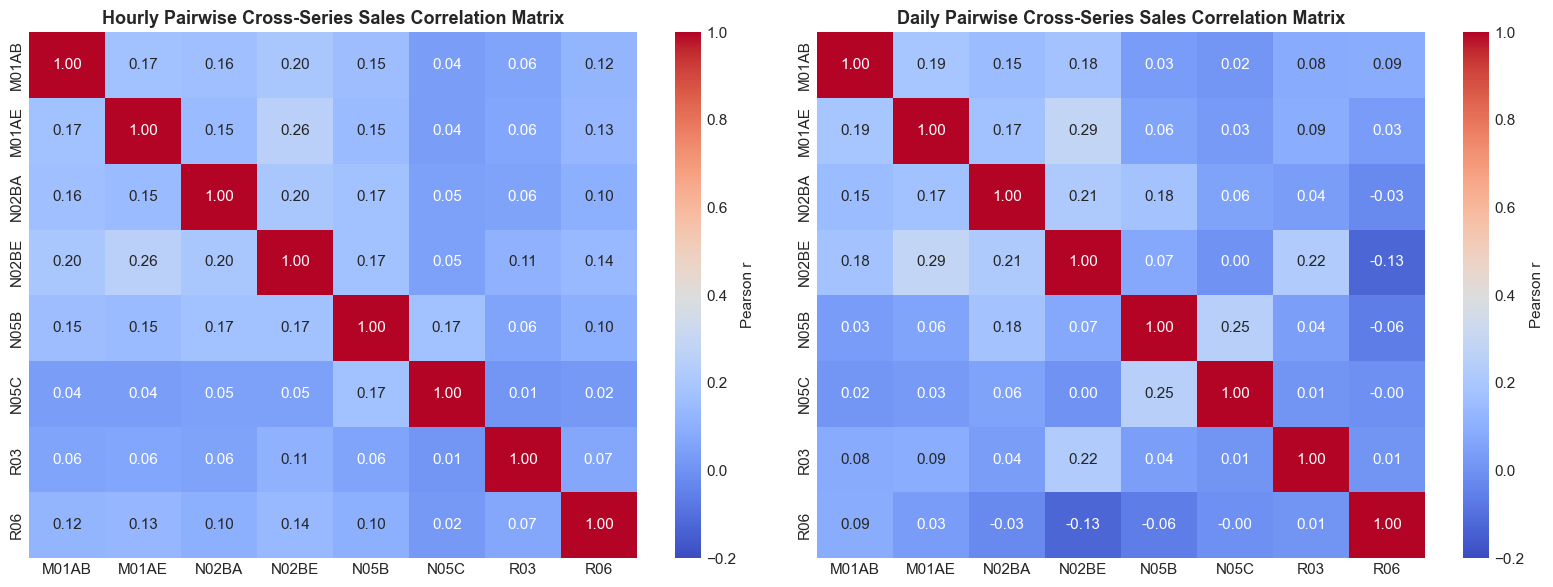

In [3]:
# Hourly and Daily Correlation Matrices
corr_hourly = df_cross[drug_cols].corr()
corr_daily = df_daily.corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Hourly Heatmap
sns.heatmap(corr_hourly, cmap='coolwarm', annot=True, fmt=".2f", vmin=-0.2, vmax=1.0, ax=ax1, cbar_kws={'label': 'Pearson r'})
ax1.set_title("Hourly Pairwise Cross-Series Sales Correlation Matrix", fontsize=13, fontweight='bold')

# Daily Heatmap
sns.heatmap(corr_daily, cmap='coolwarm', annot=True, fmt=".2f", vmin=-0.2, vmax=1.0, ax=ax2, cbar_kws={'label': 'Pearson r'})
ax2.set_title("Daily Pairwise Cross-Series Sales Correlation Matrix", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


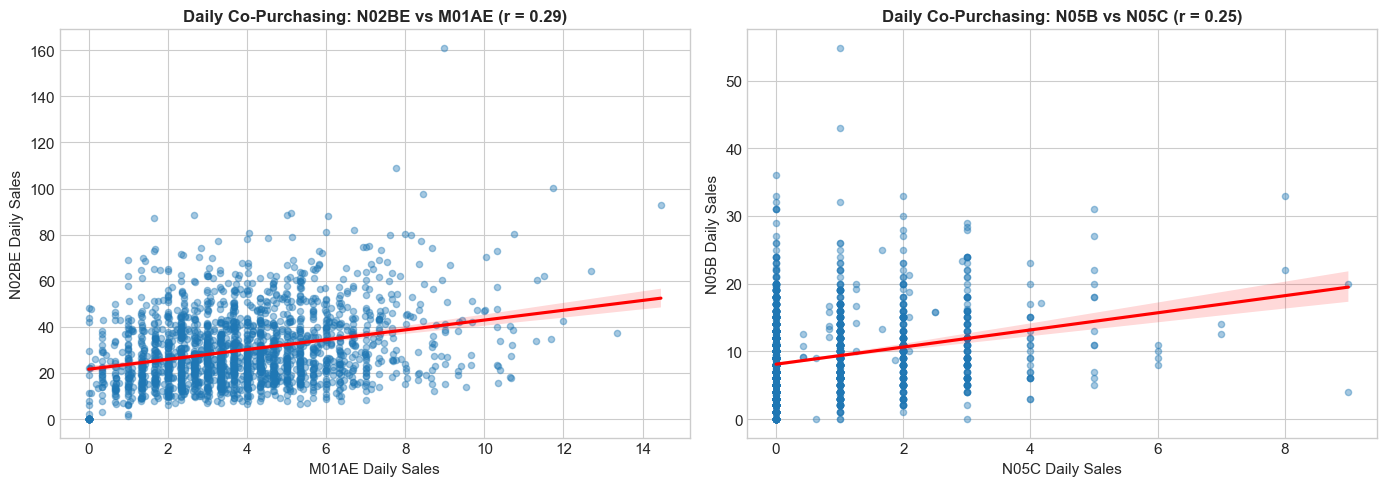

In [4]:
# Pairwise Scatter Plots for Strongest Co-Purchasing Pairs (N02BE vs M01AE & N05B vs N05C)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# N02BE vs M01AE (Daily)
sns.regplot(data=df_daily, x='M01AE', y='N02BE', ax=ax1, scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red'})
ax1.set_title(f"Daily Co-Purchasing: N02BE vs M01AE (r = {corr_daily.loc['N02BE', 'M01AE']:.2f})", fontsize=12, fontweight='bold')
ax1.set_xlabel("M01AE Daily Sales")
ax1.set_ylabel("N02BE Daily Sales")

# N05B vs N05C (Daily)
sns.regplot(data=df_daily, x='N05C', y='N05B', ax=ax2, scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red'})
ax2.set_title(f"Daily Co-Purchasing: N05B vs N05C (r = {corr_daily.loc['N05B', 'N05C']:.2f})", fontsize=12, fontweight='bold')
ax2.set_xlabel("N05C Daily Sales")
ax2.set_ylabel("N05B Daily Sales")

plt.tight_layout()
plt.show()


## 36. Cross-Series Lagged Correlation

Compute Cross-Correlation Functions (CCF) between category pairs $X_{t-k}$ and $Y_t$ across lags $k \in [-24, +24]$ hours to detect lead-lag relationships and cross-category momentum.


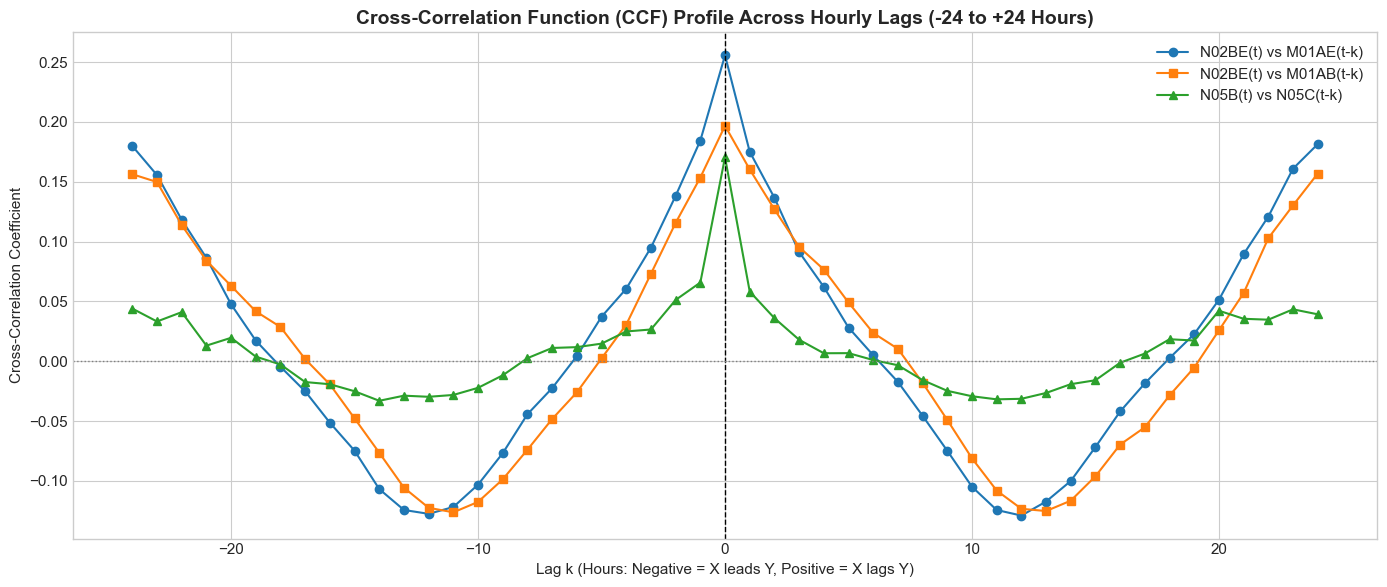

In [5]:
# Calculate Cross-Correlation Function (CCF) for Selected Category Pairs
lags = range(-24, 25)

# Pair 1: N02BE vs M01AE
ccf_n02be_m01ae = [df_cross['N02BE'].corr(df_cross['M01AE'].shift(k)) for k in lags]

# Pair 2: N02BE vs M01AB
ccf_n02be_m01ab = [df_cross['N02BE'].corr(df_cross['M01AB'].shift(k)) for k in lags]

# Pair 3: N05B vs N05C
ccf_n05b_n05c = [df_cross['N05B'].corr(df_cross['N05C'].shift(k)) for k in lags]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(lags, ccf_n02be_m01ae, marker='o', linewidth=1.5, label='N02BE(t) vs M01AE(t-k)')
ax.plot(lags, ccf_n02be_m01ab, marker='s', linewidth=1.5, label='N02BE(t) vs M01AB(t-k)')
ax.plot(lags, ccf_n05b_n05c, marker='^', linewidth=1.5, label='N05B(t) vs N05C(t-k)')

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_title("Cross-Correlation Function (CCF) Profile Across Hourly Lags (-24 to +24 Hours)", fontsize=14, fontweight='bold')
ax.set_xlabel("Lag k (Hours: Negative = X leads Y, Positive = X lags Y)")
ax.set_ylabel("Cross-Correlation Coefficient")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


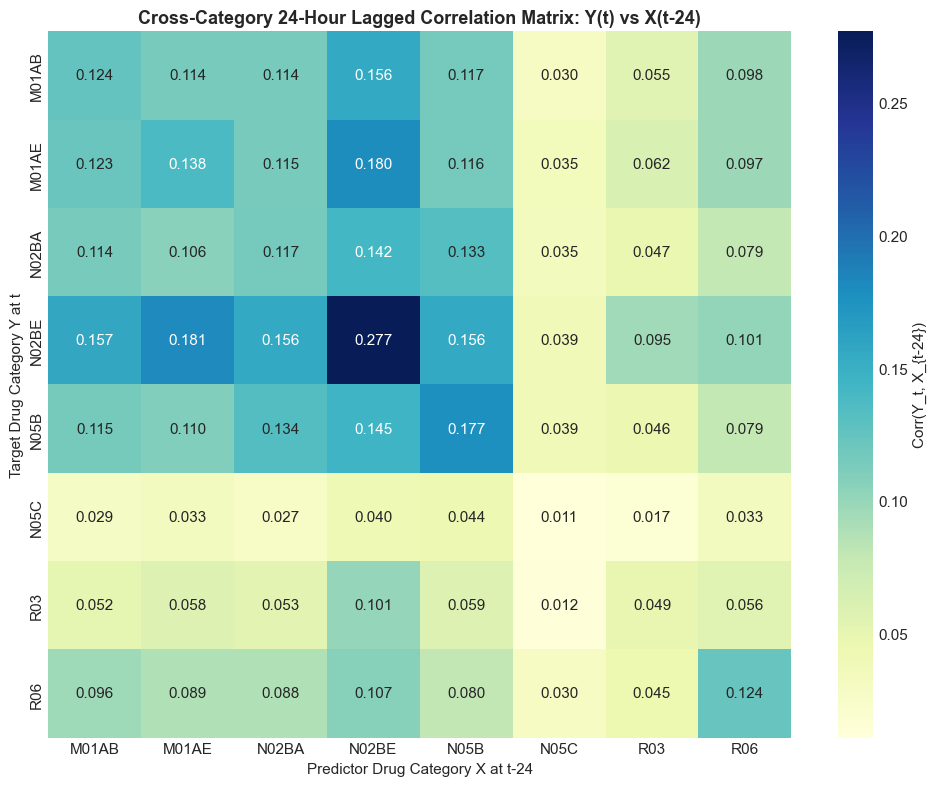

In [6]:
# Cross-Category 24-Hour Lagged Correlation Matrix: Corr(Y_t, X_{t-24})
lag24_matrix = pd.DataFrame(index=drug_cols, columns=drug_cols)

for target_col in drug_cols:
    for predictor_col in drug_cols:
        lag24_matrix.loc[target_col, predictor_col] = df_cross[target_col].corr(df_cross[predictor_col].shift(24))

lag24_matrix = lag24_matrix.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(lag24_matrix, cmap='YlGnBu', annot=True, fmt=".3f", ax=ax, cbar_kws={'label': 'Corr(Y_t, X_{t-24})'})
ax.set_title("Cross-Category 24-Hour Lagged Correlation Matrix: Y(t) vs X(t-24)", fontsize=13, fontweight='bold')
ax.set_xlabel("Predictor Drug Category X at t-24")
ax.set_ylabel("Target Drug Category Y at t")
plt.tight_layout()
plt.show()


## 37. Summary of Findings & Key Takeaways

Below is the consolidated summary of the Cross-Series and Cross-Lagged Correlation findings across modules 35 and 36:

| Analysis Module | Metric / Evaluation | Key Empirical Finding | Multivariate Modeling Implication |
| :--- | :--- | :--- | :--- |
| **35. Cross-Series Correlation** | Contemporaneous Pairwise $r$ | Strongest co-purchasing correlation between `N02BE` & `M01AE` ($r = 0.292$ daily) and `N05B` & `N05C` ($r = 0.247$ daily). | Shared demand drivers (e.g. analgesics + anti-inflammatory co-prescription) suggest joint multi-target modeling. |
| **36. Cross-Series Lagged CCF** | Cross-Lagged Correlation $X_{t-k} 	o Y_t$ | Peak CCF occurs at $k=0$ and $k=24$ (daily return cycle). Cross-category 24h lags show positive correlation ($r = 0.156$ for `N02BE` vs `M01AB_{t-24}`). | Include cross-category lag features ($M01AE_{t-24}$, $M01AB_{t-24}$) when predicting target $N02BE_t$ in GBDT models. |

---

### Final Multivariate Modeling Recommendations
1. **Cross-Category Lag Features**: In multi-output GBDT models (LightGBM/XGBoost), include lag features from correlated drug categories (e.g., $M01AE_{t-24}$ as an exogenous feature for predicting $N02BE_t$).
2. **Joint Multi-Target Learning**: Utilize multi-output neural networks (e.g. Multi-Task LSTM/GRU) to jointly learn shared representation layers across all 8 ATC drug categories.
